<a href="https://colab.research.google.com/github/michalshavitNYU/Waves/blob/main/third_stage_wilton_ripple_high.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kfac_jax==0.0.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.5/313.5 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,

In [ ]:
import sys
import jax
import jax.numpy as jnp

import numpy as np
import optax

import abc

from jax import random, vjp, vmap
from jax.tree_util import tree_map
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.io import savemat
from scipy.interpolate import interp1d
from pathlib import Path
import pickle

In [ ]:
import kfac_jax

In [ ]:
from kfac_jax import curvature_estimator
from kfac_jax import curvature_blocks
from kfac_jax import layers_and_loss_tags
from kfac_jax import loss_functions as kfac_loss_functions
from kfac_jax import optimizer as kfac_optim

In [ ]:
import os
import requests

from jax import random
from jax.tree_util import tree_map

In [ ]:
# change JAX to double precision
jax.config.update('jax_enable_x64', True)

# define the root path
rootdir = Path('/content/drive').joinpath('MyDrive')

# Customized function for collocation point arrangement

In [ ]:
import scipy
import jax.scipy as jsp

def gaussian1D_smooth(f, sig, wid):
    '''
    :param f: equally spaced 1D position matrix  (N, 1)
    :param sig: stan. devi of gaussian filter (1, ) or scalor
    :param wid: wid of the filter matrix (1, ) or scalor integer
    '''
    wid = jnp.int32(wid)
    xg = jnp.linspace(-sig, sig, wid)
    window = jsp.stats.norm.pdf(xg)
    win_n = window / jnp.sum(window)
    f_smooth = scipy.signal.convolve(f[:, 0], win_n, mode='same')[:, None] #f[:, 0] selects the first (and only) column of f, turning it into a 1D array of shape (N,).
    return f_smooth


# sample the data based on a given probability distribution
def colloc1D_set(key, x, f, Ns):
    '''
    :param x: 1-D position array (N, 1)
    :param f: 1-D distribution array (N, 1)
    :param Ns: number of points to sample
    '''
    # remove last element in each direction
    xc = x[0:-1, :]
    fc = f[0:-1, :]
    dx = xc[1] - xc[0]
    seq = jnp.arange(fc.shape[0] + 1)
    # generate key for random variables
    keys = jax.random.split(key, num=2)

    # obtain the cumulative sum of the z value
    b = jnp.hstack([0., jnp.cumsum(fc)])
    # obtain the random variable
    c = jax.random.uniform(keys[0], [Ns]) * b[-1]
    # generate the index position of each collocation point following the distribution
    # (using the interpolate the index of grid where each random variable stands)
    posi_intp = jnp.interp(c, b, seq)
    # round the result to guarantee that the index position is integer
    posi = jnp.int32(jnp.floor(posi_intp))
    # obtain the real position of each collocation point
    px = xc[posi, :]
    # generate a random fraction for each collocation point
    posi_add = jax.random.uniform(keys[1], [c.shape[0], 1])
    # add the random fraction to the position of each collocation points
    x_col = px + posi_add * dx

    return x_col


# Weight initialization and network architecture

In [ ]:
# ============================================================
# Initialize one MLP
# Format: list of [W, b]
# ============================================================

def init_MLP(parent_key, layer_widths):
    params = []
    keys = random.split(parent_key, num=len(layer_widths) - 1)

    for in_dim, out_dim, key in zip(layer_widths[:-1], layer_widths[1:], keys):
        weight_key, bias_key = random.split(key)

        xavier_stddev = jnp.sqrt(2.0 / (in_dim + out_dim))

        W = random.truncated_normal(
            weight_key, -2.0, 2.0, shape=(in_dim, out_dim)
        ) * xavier_stddev

        b = random.truncated_normal(
            bias_key, -2.0, 2.0, shape=(out_dim,)
        ) * xavier_stddev

        params.append([W, b])

    return params


# ============================================================
# Initialize all networks and free parameters
# ============================================================

def stwv_init_MLP(parent_key, n_hl, n_unit):
    """
    Returns:
        params = [net1, net2, net3, beta_mod, lamb_mod]
    """

    layers = [1] + n_hl * [n_unit] + [1]

    _, key1, key2, key3 = random.split(parent_key, 4)

    net1 = init_MLP(key1, layers)
    net2 = init_MLP(key2, layers)
    net3 = init_MLP(key3, layers)

    beta_mod = jnp.array([0.0], dtype=jnp.float64)
    lamb_mod = jnp.array([0.0], dtype=jnp.float64)

    params = [net1, net2, net3, beta_mod, lamb_mod]

    return params


parent_key = random.PRNGKey(0)

params = stwv_init_MLP(
    parent_key=parent_key,
    n_hl=3,
    n_unit=30,
)

In [ ]:
import urllib.parse

# ============================================================
# Choose stage-1 weights file
# ============================================================

# Stage-1 speed and surface tension for the checkpoint loaded below. These two
# numbers and the checkpoint must come from the SAME run: params below is a
# fresh network (lamb_mod = 0), so the training speed is exactly lamb0 = lamb1,
# with no tanh correction to absorb a mismatch. Verified on the Waves-repo
# checkpoint StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl:
#
#     lamb = 1.167786478283629  ->  rms(e1) = 1.3e-03   (stage-1 run's CENTRE)
#     lamb = 1.168786478283629  ->  rms(e1) = 2.8e-09   (what it CONVERGED to)
#
# The centre is what gets typed by mistake; the converged value is what names
# the file. The baseline-check cell recomputes this from whatever actually
# loads -- trust that over this comment.
lamb1 = 1.168786478283629
beta1 = 0.4980
g = 1.0

# "github" first is the safe default: a second-stage run saves its own params
# under this same naming scheme, so a stale local file can shadow the stage-1
# solution and load an untrained network as the surface.
LOAD_FROM = "github"          # "github" or "local"

ExpName = f"StokesWave_lamd={lamb1:.4f}_beta={beta1:.4f}_g={g:.1f}"
local_weights_path = str(rootdir.joinpath(ExpName + "_weights.pkl"))

# Derived from ExpName so the two sources cannot drift to different runs.
github_weights_url = (
    "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
    + urllib.parse.quote(ExpName + "_weights.pkl", safe="")
)
print("expecting checkpoint:", ExpName + "_weights.pkl")


# ============================================================
# Load previous stage-1 parameters
# ============================================================

def _load_local(path):
    if path is None or not os.path.exists(path):
        print(f"   local file not found: {path}")
        return None
    with open(path, "rb") as f:
        p = pickle.load(f)
    print(f"✅ Loaded params0 from local file:\n   {path}")
    return p


def _load_github(url):
    if url is None:
        return None
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        print(f"   GitHub returned {r.status_code} for\n   {url}")
        return None
    with open("downloaded_stage1_weights.pkl", "wb") as f:
        f.write(r.content)
    with open("downloaded_stage1_weights.pkl", "rb") as f:
        p = pickle.load(f)
    print(f"✅ Downloaded and loaded params0 from GitHub:\n   {url}")
    return p


def load_stage1_params(weights_path=None, github_url=None, prefer="github"):
    order = ["github", "local"] if prefer == "github" else ["local", "github"]
    params0 = None
    for src in order:
        print(f"trying {src} ...")
        params0 = _load_github(github_url) if src == "github" else _load_local(weights_path)
        if params0 is not None:
            break

    if params0 is None:
        raise FileNotFoundError(
            "Could not load params0 from GitHub or the local file.\n"
            f"  url  : {github_url}\n  local: {weights_path}\n"
            "Check that lamb1/beta1 name a checkpoint that exists."
        )

    # old format: [net1, net2, net3, lamb_mod] -> new: [..., beta_mod, lamb_mod]
    if len(params0) == 4:
        print("⚠️ Old format detected: [net1, net2, net3, lamb_mod]. Adding beta_mod = 0.")
        params0 = params0[:3] + [jnp.array([0.0], dtype=jnp.float64), params0[3]]

    print("\nFinal params0:")
    print("len =", len(params0))
    print("beta_mod =", params0[3])
    print("lamb_mod =", params0[4])
    return params0


params0 = load_stage1_params(
    weights_path=local_weights_path,
    github_url=github_weights_url,
    prefer=LOAD_FROM,
)

# Is this actually a trained stage-1 solution, or a second-stage params dump?
_tanh_lamb = float(jnp.tanh(params0[-1])[0])
_tanh_beta = float(jnp.tanh(params0[-2])[0])
print(f"\nstage-1 tanh(lamb_mod) = {_tanh_lamb:+.10f}")
print(f"stage-1 tanh(beta_mod) = {_tanh_beta:+.10f}")

if float(params0[-2][0]) == 0.0 and abs(_tanh_lamb) < 1e-2:
    print(
        "\n\u26a0\ufe0f  beta_mod is exactly 0 and lamb_mod is ~0: this looks like an\n"
        "    UNTRAINED network, i.e. a second-stage params dump rather than a\n"
        "    stage-1 solution. Expect t2 ~ 0.05 instead of reaching ~1."
    )
elif abs(_tanh_lamb) > 0.999:
    print(
        "\n\u26a0\ufe0f  stage-1 lamb_mod is saturated: that run hit its \u00b1eta bound, so its\n"
        "    converged speed sits one full eta away from the centre it was given."
    )

expecting checkpoint: StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl
trying github ...
✅ Downloaded and loaded params0 from GitHub:
   https://raw.githubusercontent.com/michalshavitNYU/Waves/main/StokesWave_lamd%3D1.1688_beta%3D0.4980_g%3D1.0_weights.pkl

Final params0:
len = 5
beta_mod = [-8.38131234]
lamb_mod = [11.74643227]

stage-1 tanh(lamb_mod) = +0.9999999999
stage-1 tanh(beta_mod) = -0.9999998950

⚠️  stage-1 lamb_mod is saturated: that run hit its ±eta bound, so its
    converged speed sits one full eta away from the centre it was given.


In [ ]:
%%script false --no-raise-error
import urllib.parse

# ============================================================
# Choose stage-1 weights file
# ============================================================

# Stage-1 speed and surface tension for the checkpoint loaded below.
#
# These two numbers and the checkpoint have to come from the SAME run. Because
# params below is a fresh network (lamb_mod = 0), the training speed is exactly
# lamb0 = lamb1 -- there is no tanh correction to absorb a mismatch, so an error
# here goes straight into the residual. Measured on the Waves-repo checkpoint
# StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl:
#
#     lamb = 1.167786478283629  ->  rms(e1) = 1.3e-03
#     lamb = 1.168786478283629  ->  rms(e1) = 2.8e-09   (least-squares optimum)
#
# The baseline-check cell after the problem setup recomputes this from whatever
# checkpoint actually loads and prints the speed to use. Trust that over this
# comment: if the two disagree, the file being loaded is not the one these
# numbers came from.
lamb1 = 1.167786478283629
beta1 = 0.4980
g = 1.0

ExpName = f"StokesWave_lamd={lamb1:.4f}_beta={beta1:.4f}_g={g:.1f}"

local_weights_path = str(rootdir.joinpath(ExpName + "_weights.pkl"))

# Derived from ExpName so the remote fallback cannot silently drift to a
# different run than the local path -- that is how a 1.1688 checkpoint ends up
# being scored at 1.1678.
github_weights_url = (
    "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
    + urllib.parse.quote(ExpName + "_weights.pkl", safe="")
)
print("expecting checkpoint:", ExpName + "_weights.pkl")


# github_weights_url = (
#     "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
#     "StokesWave_lamd%3D1.1668_beta%3D0.5000_g%3D1.0_weights.pkl"
# )


# ============================================================
# Load previous stage-1 parameters
# ============================================================

def load_stage1_params(weights_path=None, github_url=None):
    params0 = None

    # Try local file first
    if weights_path is not None and os.path.exists(weights_path):
        with open(weights_path, "rb") as f:
            params0 = pickle.load(f)

        print(f"✅ Loaded params0 from local file:\n{weights_path}")

    # Try GitHub if local loading failed
    if params0 is None and github_url is not None:
        print("Trying GitHub URL:")
        print(github_url)

        response = requests.get(github_url)

        if response.status_code == 200:
            tmp_path = "downloaded_stage1_weights.pkl"

            with open(tmp_path, "wb") as f:
                f.write(response.content)

            with open(tmp_path, "rb") as f:
                params0 = pickle.load(f)

            print("✅ Downloaded and loaded params0 from GitHub.")

        else:
            raise RuntimeError(
                f"GitHub download failed with status code {response.status_code}"
            )

    if params0 is None:
        raise FileNotFoundError("Could not load params0 from local file or GitHub.")

    # Backward compatibility:
    # old format: [net1, net2, net3, lamb_mod]
    # new format: [net1, net2, net3, beta_mod, lamb_mod]
    if len(params0) == 4:
        print("⚠️ Old format detected: [net1, net2, net3, lamb_mod].")
        print("Adding beta_mod = 0.")

        beta_mod = jnp.array([0.0], dtype=jnp.float64)
        params0 = params0[:3] + [beta_mod, params0[3]]

    print("\nFinal params0:")
    print("len =", len(params0))
    print("beta_mod =", params0[3])
    print("lamb_mod =", params0[4])

    return params0


params0 = load_stage1_params(
    weights_path=local_weights_path,
    github_url=github_weights_url,
)

# params0[-1] / params0[-2] are the stage-1 lamb_mod / beta_mod. Saturated
# values mean that run pushed its speed to the edge of its own +/- eta window.
_tanh_lamb = float(jnp.tanh(params0[-1])[0])
_tanh_beta = float(jnp.tanh(params0[-2])[0])
print(f"\nstage-1 tanh(lamb_mod) = {_tanh_lamb:+.10f}")
print(f"stage-1 tanh(beta_mod) = {_tanh_beta:+.10f}")
if abs(_tanh_lamb) > 0.999:
    print(
        "\u26a0\ufe0f  stage-1 lamb_mod is saturated: that run hit its \u00b1eta1 bound, so its\n"
        "    converged speed sits one full eta1 away from the centre it was given.\n"
        "    If lamb1 above was copied from that centre it is short by exactly eta1."
    )


In [ ]:
def linfun(x):
    return x

# define sech function
def sech(z):
    return 1 / jnp.cosh(z)


def network_core(params, H):
    # separate the first, hidden and last layers
    first, *hidden, last = params
    # calculate the first layers output with right scale
    H = jnp.tanh(jnp.dot(H, first[0]) + first[1])
    # calculate the middle layers output
    for layer in hidden:
        H = jnp.tanh(jnp.dot(H, layer[0]) + layer[1])
    # no activation function for last layer
    var = jnp.dot(H, last[0]) + last[1]
    return var


# # define the basic formation of neural network
# def neural_net_even(params, x, limit):
#     '''
#     :param params: weights and biases
#     :param limit: characteristic scale for normalization [matrix with shape [2, m]]
#     :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
#     '''
#     pd = limit[0]  # half period in x and length in y
#     # normalize the input
#     th = x / pd
#     # double the variable in r direction
#     H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
#     # calculate the output for all networks
#     var0 = network_core(params[0], H)
#     var1 = network_core(params[1], H) * jnp.sin(jnp.pi*th)
#     var2 = network_core(params[2], H)
#     return jnp.hstack([var0, var1, var2])  #another option: return var0, var1

#dfq is dominant freq of residue
def network_fourier(params, H, dfq):
    # separate the first, hidden and last layers
    first, *hidden, last = params
    # calculate the first layers output with right scale
    H = jnp.sin(jnp.dot(H, first[0]*dfq) + first[1])
    # calculate the middle layers output
    for layer in hidden:
        H = jnp.sin(jnp.dot(H, layer[0]) + layer[1]) #check with yongji if should be H = jnp.tanh(jnp.dot(H, layer[0]) + layer[1])
    # no activation function for last layer
    var = jnp.dot(H, last[0]) + last[1]
    return var


# epsilonp scales the correction network. At exactly 0 the correction term
# drops out of predf, so its weights have identically zero gradient and this
# stage trains nothing but lamb (and beta, if eta_beta != 0). Keep 0 for the
# baseline residual check, then set it nonzero to actually train the correction.
epsilonp = 1e-9 #0. #10**(-1)
sclp = 0.27 #sclp is scl from previous training
dfq = 50. # need to test the best value of it, dominant freq of residue

# set the size of domain #this is a duplicate for now, need to clean later
pd = jnp.pi
scl = 0.27
lmt = jnp.array([pd, scl])


def neural_net_fourier(params, x, limit, dfq):
    '''
    :param params: weights and biases
    :param limit: characteristic scale for normalization [matrix with shape [2, m]]
    :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
    '''
    pd = limit[0]  # half period in x and length in y
    # normalize the input
    th = x / pd
    # double the variable in r direction
    H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
    # calculate the output for all networks
    var0 = network_fourier(params[0], H, dfq)
    var1 = network_fourier(params[1], H, dfq) * jnp.sin(jnp.pi*th) ##if doesnt work check if needs to be fourier dfq
    var2 = network_fourier(params[2], H, dfq)
    return jnp.hstack([var0, var1, var2])  #another option: return var0, var1


    # define the basic formation of neural network
def neural_net_even(params, x, limit):
    '''
    :param params: weights and biases
    :param limit: characteristic scale for normalization [matrix with shape [2, m]]
    :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
    '''
    pd = limit[0]  # half period in x and length in y
    # normalize the input
    th = x / pd
    # double the variable in r direction
    H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
    # calculate the output for all networks
    var0 = network_core(params[0], H)
    var1 = network_core(params[1], H) * jnp.sin(jnp.pi*th)
    var2 = network_core(params[2], H)
    return jnp.hstack([var0, var1, var2])  #another option: return var0, var1

# for second stage training we define the base function from pevious training

def prepare_from_stage1(params,limit):
    def y_p(x):
        return sclp * neural_net_even(params[0:3], x, limit)
    return y_p


y_p = prepare_from_stage1(params0,lmt) # previous trained params0



def stwv_pred_create(limit):
    '''
    :param limit: domain size of the input
    :return: function of the solution (a callable)
    '''
    pd, scl = limit  # half period in x and length in y
    # high-level architecture for IPM solution
    def f(params, x):
        # calculate the raw network output
        y =  y_p(x) + epsilonp * neural_net_fourier(params[0:3], x, limit, dfq) #was params[0] #maybe dont need to multiply by scl?
        #y = neural_net_even(params[0:3], x, limit) #was params[0] #maybe dont need to multiply by scl?
        return y
    return f






def stwv_pred_create_test(limit, m,n):
    '''
    :param limit: domain size of the input
    :return: function of the solution (a callable)
    '''
    pd, scl = limit  # half period in x and length in y
    # high-level architecture for IPM solution
    def f(params, x):
        # calculate the raw network output
        y = scl * (jnp.cos(m*x) + jnp.cos(n*x)) + neural_net_even(params[0:3], x, limit)*0  #was params[0]
        return y
    return f


# numiercal Periodic Hilbert Transform

In [ ]:
"""High-precision numerical calculation of Hilbert *transform*"""


def hilb_bd_detect(x, xn, n):
    # detect the position of data in xn that is next to x
    vn0 = xn - x
    tn = jnp.tan(vn0 / 2)
    # convert the vn to the new range from -pi to pi
    vn = 2 * jnp.arctan(tn)   # very important step
    # compute the p variable based on the new vn
    pn = jnp.sin(vn / 2)
    # find the least positive and most negative points
    tn0 = tn - (tn > -1e-16) * jnp.inf
    tn1 = tn + (tn < 1e-16) * jnp.inf
    idxb0 = jnp.argmin(-tn0)
    idxb1 = jnp.argmin(tn1)
    # distance of those point withe respect zero
    hp0 = -pn[idxb0]
    hp1 = pn[idxb1]
    hpm = (hp0 + hp1)/2
    # prepare the nodes for inner domain integration with respect to vn
    p_front = -jnp.arange(n, 0, -2) * hpm / n
    p_rear = jnp.arange(1, n + 1, 2) * hpm / n
    p_inner = jnp.hstack([p_front, p_rear])
    # convert the node back to original coordinate
    x_in = jnp.arcsin(p_inner) * 2 + x

    # detect the boundary for the closer region
    tnc0 = tn - (tn >= -15 * hpm) * jnp.inf
    tnc1 = tn + (tn <= 15 * hpm) * jnp.inf
    idxc0 = jnp.argmin(-tnc0)
    idxc1 = jnp.argmin(tnc1)
    # compute the tn value for the closest point
    tn_cl = jnp.array([tn[idxc0], tn[idxc1]])
    # compute the pn value for the closest point
    pn0_cl = pn[idxc0]
    pn1_cl = pn[idxc1]
    # compute the qn value for the closest point to pn_bd[0]
    qn0_cl = jnp.flip(jnp.log(-pn0_cl))
    qn1_cl = jnp.log(pn1_cl)
    # compute the qn value for the inner point
    qn0_bd = jnp.flip(jnp.log(hpm))
    qn1_bd = jnp.log(hpm)
    # create the node point in qn for the closer region
    qn0 = jnp.linspace(qn0_bd, qn0_cl, 8)
    qn1 = jnp.linspace(qn1_bd, qn1_cl, 8)
    return x_in, qn0, qn1, tn_cl


def hilbtrans_close(x, q1n, q2n, func, params_c):
    '''
    hilbert transform of one single output using non-uniform sampling
    based on Bilato's paper with O(h^2) accuracy
    '''
    # unroll the params
    ni, wi = params_c
    # compute the bound for each gaussian quadrature (GQ) integral
    a1 = q1n[0:-1]
    b1 = q1n[1:]
    a2 = q2n[0:-1]
    b2 = q2n[1:]
    # normalize the gaussian quadrature range
    q1i = (b1 - a1) / 2 * ni + (a1 + b1) / 2
    q2i = (b2 - a2) / 2 * ni + (a2 + b2) / 2
    # compute the corresponding x value for the GQ interpolation point
    x1i = 2 * jnp.arcsin(-jnp.exp(q1i))
    x2i = 2 * jnp.arcsin(jnp.exp(q2i))
    x1i = x1i + x
    x2i = x2i + x
    # calculate the integrand of Gaussian quadrature
    f1 = vmap(func, in_axes=0)(x1i[:, :, None])[:, :, 0]
    f2 = -vmap(func, in_axes=0)(x2i[:, :, None])[:, :, 0]
    # calculate using Gaussian Quadrature
    close1 = (b1 - a1) / 2 * jnp.matmul(wi, f1)[0]
    close2 = (b2 - a2) / 2 * jnp.matmul(wi, f2)[0]
    close_all = jnp.hstack((close1, close2))
    # sum all the sub-integral
    closesum = jnp.sum(close_all)[None]
    return closesum


def hilbInt_outer(x, tn_cl, params_o):
    '''
    hilbert transform of one single output using non-uniform sampling
    based on Bilato's paper with O(h^2) accuracy
    '''
    # unroll the params
    xn, a, b, xi, fxi, ni, wi = params_o
    # detect the position of data in xn that is next to x
    vn = xn - x
    tn = jnp.tan(vn / 2)
    sg = (tn < tn_cl[0]-2e-16) | (tn >= tn_cl[1])
    # calculate the integrand of Gaussian quadrature
    fh = fxi / jnp.tan((x - xi) / 2) / 2
    # calculate using Gaussian Quadrature
    outer = (b-a) / 2 * jnp.matmul(wi, fh)[0] * sg[0:-1]
    outsum = jnp.sum(outer)[None]
    return outsum


def hilb_perid_cubic(xn):
    '''
    hilbert transform of multiple outputs at any positions
    within the range of sampling points
    params func: function with respect to z (not x)
    '''
    # order of the method
    n = 3
    # flatten the sampling point (for output shape)
    xn = xn.flatten()
    # set the Gaussian Quadrature nodes  (order 9)
    e1 = jnp.array(1 / 3 * jnp.sqrt(5 - 2 * jnp.sqrt(10 / 7)))
    e2 = jnp.array(1 / 3 * jnp.sqrt(5 + 2 * jnp.sqrt(10 / 7)))
    # set the Gaussian Quadrature weights (order 9)
    c1 = jnp.array((322 - 13 * jnp.sqrt(70)) / 900)
    c2 = jnp.array((322 + 13 * jnp.sqrt(70)) / 900)
    c3 = jnp.array(128 / 225)
    # group and match the weights and nodes
    ni = jnp.vstack([-e2, -e1, 0, e1, e2])
    wi = jnp.hstack([c1, c2, c3, c2, c1])[None, :]
    # prepare the outer domain integration
    a = xn[0:-1]
    b = xn[1:]
    # change of variables
    xi = (b - a) / 2 * ni + (a + b) / 2

    def hpfunc(x, func):
        # obtain the position info for the inner and closer domain
        x_in, q1n, q2n, tn_cl = vmap(hilb_bd_detect, in_axes=(0, None, None))(x, xn, n)
        # prepare the nodes for inner domain integration
        f_in = vmap(func, in_axes=0)(x_in[:, :, None])[:, :, 0]
        # coefficient based on LG interpolation
        c_in = jnp.array([1/4, 9/4, -9/4, -1/4])
        # calculate the inner domain integration
        Iinner = jnp.sum(c_in * f_in, axis=1)[:, None]

        # group parameters required for close domain calculation
        params_c = [ni, wi]
        # calculation the close domain integration
        Iclose = vmap(hilbtrans_close, in_axes=(0, 0, 0, None, None))(x, q1n, q2n, func, params_c)

        # calculate the outer domain integration
        fxi = vmap(func, in_axes=0)(xi[:, :, None])[:, :, 0]
        params_o = [xn, a, b, xi, fxi, ni, wi]
        # calculation the outer domain integration
        Iouter = vmap(hilbInt_outer, in_axes=(0, 0, None))(x, tn_cl, params_o)
        # Iouter = hilbInt_outer(x[0], tn_cl[0], params_o)
        # sum up the components to the final expression
        hfx = (Iinner + Iclose + Iouter) / jnp.pi
        return hfx

    return hpfunc


# Governing equation and Loss function

In [ ]:
"""
Low-level functions for Stokes-wave PINN training in JAX.

Assumptions:
- jax, jax.numpy as jnp, vjp, vmap, and kfac_loss_functions are imported.
- hptrans(x, f) implements the periodic Hilbert transform:
    hptrans(x, f) ~ H[f(x)]
- Global constants: g (gravity), beta (surface tension),
  epsilon, scl, m, (optionally n) are defined elsewhere.
"""

# -------------------------------------------------------------------
# Basic loss utilities
# -------------------------------------------------------------------

def ms_error(diff):
    """
    Mean squared error along axis=0.

    Parameters
    ----------
    diff : array, shape (N, k)
        Difference or residual values.

    Returns
    -------
    mse : array, shape (k,)
        Mean of squared entries over samples.
    """
    return jnp.mean(jnp.square(diff), axis=0)


def ms_bias(diff, weight):
    """
    Weighted sum of squared errors.

    Parameters
    ----------
    diff : array, shape (N, k)
        Residual values.
    weight : array, shape (N, k) or (N, 1)
        Quadrature weights (or general weights).

    Returns
    -------
    scalar : float
        Sum_i weight_i * diff_i^2
    """
    return jnp.sum(weight * jnp.square(diff))


# -------------------------------------------------------------------
# Autodiff helpers: vector-Jacobian products and gradient assembly
# -------------------------------------------------------------------

def vgmat(z, n_out, idx=None):
    """
    Build a selection matrix for vector-Jacobian products.

    This constructs a tensor 'mat' such that applying vjp(func, z)
    with 'mat[l, :, ii] = 1' picks out partial derivatives of output
    component 'ii'.

    Parameters
    ----------
    z : array, shape (N, d)
        Input points.
    n_out : int
        Number of output variables of func(z).
    idx : list[int] or None
        List of output indices to take gradients of.
        If None, uses range(n_out).

    Returns
    -------
    mat : array, shape (n_idx, N, n_out)
        Selection tensor for vjp.
    """
    if idx is None:
        idx = range(n_out)

    n_idx = len(idx)      # number of selected output components
    n_pt = z.shape[0]     # number of input points

    mat_shape = [n_idx, n_pt, n_out]
    mat = jnp.zeros(mat_shape)

    # For each selected output index, set the corresponding slice to 1
    for l, ii in zip(range(n_idx), idx):
        mat = mat.at[l, :, ii].set(1.0)

    return mat


def batch_mul(mat1, mat2):
    """
    Batched element-wise multiplication along first axis.

    Parameters
    ----------
    mat1 : array, shape (B, N, k)
    mat2 : array, shape (N, k)

    Returns
    -------
    mat_prod : array, shape (B, N, k)
        mat_prod[b] = mat1[b] * mat2 (element-wise).
    """
    prod = lambda x, y: jnp.multiply(x, y)
    mat_prod = vmap(prod, (0, None))
    return mat_prod(mat1, mat2)


def vectgrad(func, z):
    """
    Compute gradients of vector-valued func with respect to inputs z.

    Given func: R^d -> R^m and a batch of points z (N,d),
    returns both the flattened gradient and the function values.

    Parameters
    ----------
    func : callable
        Maps z -> array of shape (N, m).
    z : array, shape (N, d)
        Input batch.

    Returns
    -------
    grad_all : array, shape (N, d*m)
        Flattened gradient at each point.
    sol : array, shape (N, m)
        Function values func(z).
    """
    # Evaluate function and create vjp callable
    sol, vjp_fn = vjp(func, z)

    # Build selection tensor for each output component
    mat = vgmat(z, sol.shape[1])

    # vjp over the selection tensor (batched over output-index dimension)
    grad0 = vmap(vjp_fn, in_axes=0)(mat)[0]  # shape (n_idx, N, d)

    # Reorder axes -> (N, n_idx, d)
    grad_s = grad0.transpose(1, 0, 2)

    # Flatten over outputs and input dimensions -> (N, d * m)
    n_pd = z.shape[1] * sol.shape[1]
    grad_all = grad_s.reshape(z.shape[0], n_pd)

    return grad_all, sol


# -------------------------------------------------------------------
# Governing equations (Stokes travelling wave, Hilbert form)
# -------------------------------------------------------------------

def stwv_gov_eqn(func, x, lamb, beta):
    """
    Compute the residuals e1, e2, e3 of the Hilbert-form Stokes system.

    Parameters
    ----------
    func : callable
        Neural network mapping x -> [y, t1, t2],
        where x has shape (N, 1) and func(x) has shape (N, 3).
    x : array, shape (N, 1)
        Collocation points.
    lamb : float
        Wave speed parameter λ.

    Returns
    -------
    residuals : array, shape (N, 3)
        [e1, e2, e3] at each collocation point.
    """
    # Extract network outputs as functions of x
    f_y     = lambda z: func(z)[:, 0:1]  # y
    f_tens1 = lambda z: func(z)[:, 1:2]  # t1
    f_tens2 = lambda z: func(z)[:, 2:3]  # t2

    # Convenience lambda for reuse of y-derivatives
    f_yx  = lambda z: vectgrad(f_y, z)[0]
    f_yxx = lambda z: vectgrad(f_yx, z)[0]

    # First derivative y_x and value y
    y_x, y = vectgrad(f_y, x)

    # (Optional) second derivative storage - currently unused directly
    y_xx, _ = vectgrad(f_yx, x)  # kept for consistency; not used below

    # Powers of y and their derivatives
    f_ysq   = lambda z: f_y(z) ** 2
    f_yqub  = lambda z: f_y(z) ** 3
    f_yqubx = lambda z: vectgrad(f_yqub, z)[0]
    f_ysqx  = lambda z: vectgrad(f_ysq, z)[0]


    # Hilbert transforms: H[y], H[y_x], H[(y^2)_x], H[(y^3)_x]
    Hy       = hptrans(x, f_y)
    Hy_x     = hptrans(x, f_yx)
    Hy_xx     = hptrans(x, f_yxx)
    Hysq_x   = hptrans(x, f_ysqx)
    Hyqub_x  = hptrans(x, f_yqubx)  # currently unused in e1; for vorticity extensions


    #surface tension
    f_Hy_x  = lambda z: hptrans(z, f_yx)
    f_tens3 = lambda z: f_yxx(z) #/ (f_yx(z)**2 + (1 + hptrans(z, f_yx))**2)
    Htens3  = hptrans(x, f_tens3)
    ##ytens3 = y_xx #/ (jnp.sqrt(y_x**2 + (1 + Hy_x)**2))
    ##Htens3  = hptrans(x, ytens3)

    # Derivatives and Hilbert transforms for t1, t2
    dtens1, tens1 = vectgrad(f_tens1, x)  # dtens1 = t1_x
    f_dtens2 = lambda z: vectgrad(f_tens2, z)[0]  # t2_x
    tens2    = f_tens2(x)
    Htens2   = hptrans(x, f_tens2)       # H[t2]
    Hdtens2  = hptrans(x, f_dtens2)      # H[t2_x]

    # Dynamic equation residual e1:
    # -λ^2 H[y_x] + g y + (g/2) H[(y^2)_x] + g y H[y_x] + β(-t1_x + H[t2_x])
    # e1 = (
    #     -lamb**2 * Hy_x
    #     + g * y
    #     + g * 0.5 * Hysq_x
    #     + g * y * Hy_x
    #     + beta * (- y_xx) #+ beta * (-dtens1 + Hdtens2)
    # )

    #Surface tension terms March
    D =  jnp.sqrt(y_x**2 + (1 + Hy_x)**2)

    #e1 = (
    #    -lamb**2 * Hy_x + g * y
    #    + g * 0.5 * Hysq_x
    #    + g * y * Hy_x
    #    #+ beta * (- y_xx)
    #    - beta * (1 + Hy_x) * ((1 + Hy_x)*y_xx - y_x*(Hy_xx)) / D**3
    #    +beta * Hdtens2
    #    #+ beta * Htens3
    #)

    e1 = (
        -lamb**2 * Hy_x
         + g * y
         + g * 0.5 * Hysq_x
         + g * y * Hy_x
         + (beta)**2 * (-dtens1 + Hdtens2)
    )



    # - beta * y_xx/D

    # Algebraic relations for t2, t1: e2, e3
    denom = jnp.sqrt(y_x**2 + (1.0 + Hy_x)**2)

    e2 = tens2 - (1+Hy_x)/jnp.sqrt(y_x**2 + (1+Hy_x)**2)
    e3 = tens1 - (y_x / denom) #y_x

    return jnp.hstack([e1, e2, e3])


def stwv_deri_eqn(func, x, lamb, beta):
    """
    Compute the derivative residual e_d = ∂_x e1 for higher-accuracy diagnostics.

    Parameters
    ----------
    func : callable
        Neural network mapping x -> [y, t1, t2].
    x : array, shape (N, 1)
        Collocation points for derivative residual.
    lamb : float
        Wave speed λ.

    Returns
    -------
    e_d : array, shape (N, 1)
        Derivative residual of the dynamic equation.
    """
    # Extract fields
    f_y     = lambda z: func(z)[:, 0:1]
    f_tens1 = lambda z: func(z)[:, 1:2]
    f_tens2 = lambda z: func(z)[:, 2:3]

    # First derivative of y
    y_x, y = vectgrad(f_y, x)

    # Build derivative helper lambdas
    f_yx   = lambda z: vectgrad(f_y, z)[0]
    f_yxx  = lambda z: vectgrad(f_yx, z)[0]
    f_ysq  = lambda z: f_y(z) ** 2
    f_ysqx = lambda z: vectgrad(f_ysq, z)[0]
    f_ysqxx = lambda z: vectgrad(f_ysqx, z)[0]

    # Hilbert transforms of derivatives
    Hy_x  = hptrans(x, f_yx)
    Hy_xx = hptrans(x, f_yxx)
    Hysq_xx = hptrans(x, f_ysqxx)

    # Second derivatives for t1 and t2
    f_tens1_x  = lambda z: vectgrad(f_tens1, z)[0]
    f_tens1_xx = lambda z: vectgrad(f_tens1_x, z)[0]
    d2tens1    = f_tens1_xx(x)

    f_tens2_x  = lambda z: vectgrad(f_tens2, z)[0]
    f_tens2_xx = lambda z: vectgrad(f_tens2_x, z)[0]
    Hd2tens2   = hptrans(x, f_tens2_xx)

    # Derivative residual: ∂_x e1
    e_d = (
        -lamb**2 * Hy_xx
        + g * y_x
        + g * 0.5 * Hysq_xx
        + g * y_x * Hy_x
        + g * y * Hy_xx
        + (beta)**2 * (-d2tens1 + Hd2tens2)
    )

    # Note: you could also add derivative equations for e2,e3 if needed.
    return e_d


In [ ]:
# # -------------------------------------------------------------------
# # Analytical test
# # -------------------------------------------------------------------
#     def stwv_lin_gcap_eqn(func, x, lamb, g, beta):
#     """
#     Minimal linear gravity–capillary equation:
#         e1 = -lambda^2 H[y_x] + g*y - beta*y_xx

#     Parameters
#     ----------
#     func : callable
#         func(z) returns array (N, 1) with y(z).
#     x : array, shape (N, 1)
#         Collocation points.
#     lamb : float
#         Wave speed parameter λ.
#     g : float
#         Gravity.
#     beta : float
#         Surface tension coefficient.

#     Returns
#     -------
#     e1 : array, shape (N, 1)
#         Residual of the linear PDE at each x.
#     """
#     # y(x)
#     f_y = lambda z: func(z)[:, 0:1]

#     # y_x and y
#     y_x, y = vectgrad(f_y, x)

#     # y_xx: derivative of y_x
#     f_yx = lambda z: vectgrad(f_y, z)[0]
#     y_xx, _ = vectgrad(f_yx, x)

#     # Hilbert transform H[y_x]
#     Hy_x = hptrans(x, f_yx)

#     # Linear PDE residual
#     e1 = -lamb**2 * Hy_x + g * y - beta * y_xx

#     return e1

In [ ]:

# -------------------------------------------------------------------
# Loss function factory
# -------------------------------------------------------------------

def loss_create(predf, cond, lamb0, beta0, lw, ew):
    """
    Create the loss function used for PINN training.

    Parameters
    ----------
    predf : callable
        Predictor f(params, x) -> [y, t1, t2] of shape (N, 3).
    cond : dict
        Dictionary with boundary/normalization conditions:
          - 'cond_nm': (x_nm, y_nm) for normalization at x_nm.
    lamb0 : float
        Base value for λ (wave speed).
    lw : float
        Global weight for PDE loss term.
    ew : array-like
        Weights for different PDE components (currently only one used).

    Returns
    -------
    loss_fun : callable
        (params, data) -> (loss_normalized, loss_info)
    """
    def loss_fun(params, data):
        """
        Compute the total normalized loss for given params and data.

        Parameters
        ----------
        params : list
            Neural network parameters + last entry for lambda_raw.
        data : dict
            Training data and weights:
              - 'eta': scalar modifying lambda
              - 'sym': symmetry weight
              - 'delta': symmetry tolerance
              - 'col': (x_c, w_c) collocation points and weights
              - 'grad': (x_d, w_d) derivative collocation points and weights
              - 'smp': x_s for Monte Carlo averaging

        Returns
        -------
        loss_n : float
            Normalized loss = loss / lref.
        loss_info : array
            Concatenation of:
              [loss, loss_data, loss_eqn,
               norm_err, symm_err, wilt_err2, wilt_err3, mean_y,
               eqn_err_f,
               lamb]
        """
        # Scalars from data
        eta   = data['eta']
        eta_beta = data['eta_beta']
        sym   = data['sym']
        delta = data['delta']

        # Reference loss and PDE weights
        lref       = loss_fun.ref
        eqn_weight = loss_fun.ew

        # Data-term weights: [norm, sym, Wilton+, Wilton-, mean]
        # NOTE: some entries are currently zero (Wilton/mean off if set to 0)
        #data_weight = jnp.array([1.0, sym, 1.0, 0.0, 0.0])
        data_weight = jnp.array([1.0, sym, 0.0, 0.0, 0.0])

        # NN function in the right signature
        func = lambda z: predf(params, z)
        f_y  = lambda z: func(z)[:, 0:1]
        f_yx = lambda z: vectgrad(f_y, z)[0]

        # Trainable lambda:
        #   lamb = lamb0 + eta * tanh(lambda_raw)
        beta_raw = params[-2]
        lambda_raw = params[-1]
        lamb = lamb0 + eta * jnp.tanh(lambda_raw)
        beta = beta0 + eta_beta * jnp.tanh(beta_raw) #added April



        # Normalization condition data (fixed)
        x_nm, y_nm = cond['cond_nm']  # (points, target values)

        # Collocation sets
        x_c, w_c = data['col']   # PDE collocation points
        x_d, w_d = data['grad']  # derivative collocation points
        x_s      = data['smp']   # sample points for mean

        # Convenience points for constraints
        x_0   = jnp.array([[0.0]])
        x_pi  = jnp.array([[jnp.pi]])
        x_mpi = jnp.array([[jnp.pi / (2 * m)]])  # for Wilton-type or symmetry

        # Evaluate network at constraint points
        y_nm_p = func(x_nm)[:, 0:1]
        y_0    = func(x_0)[:, 0:1]
        y_pi   = func(x_pi)[:, 0:1]
        y_mpi  = func(x_mpi)[:, 0:1]

        # Second derivative at x=0 (currently not used in active losses)
        d2y_0 = vectgrad(f_yx, x_0)[0]

        # PDE residuals
        f_c = stwv_gov_eqn(func, x_c, lamb, beta)    # main PDE residual [e1,e2,e3]
        f_d = stwv_deri_eqn(func, x_d, lamb, beta)   # derivative residual e_d

        # --------------------------------------------------------------
        # Data / structural error terms (scalar)
        # --------------------------------------------------------------

        # 1. Normalization: y(x_nm) >= y_nm
        norm_err = ms_error(jax.nn.relu(y_nm - y_nm_p))
        #norm_err = ms_error((y_nm - y_nm_p))


        # 2. Symmetry: |y(0) - y(pi/(2m))| > delta
        #symm_err = ms_error(jax.nn.relu(delta - jnp.abs(y_0 - y_mpi)))
        symm_err = ms_error(jax.nn.relu(delta - jnp.abs(y_0 - y_pi))) #larger
        #symm_err = ms_error(jax.nn.relu(-delta + jnp.abs(y_0 - y_pi))) #smaller


        ##Crappers
        crest_to_trough =  y_0 - y_pi
        lamb_crapper = (1.0 + crest_to_trough**2 / 16.0) ** (-0.25)
        #symm_err = ms_error(lamb - lamb_crapper)


        # 3, Secon derivative at zero
        # Wilton ripple condition at x = 0: fix second derivative
        target_d2y0 = -(n * n * a_n + m * m * a_m)   # scalar or array
        ##wilt_err2 = ms_error(d2y_0 - target_d2y0)
        band_d2y0 = 7.0 * a_n**2
        wilt_err2 = ms_error(jax.nn.relu(jnp.abs(d2y_0 - target_d2y0) - band_d2y0))

        # 3 & 4. Wilton-like constraints at x=pi:
        # target ~ scl + scl^2/4; band controlled by epsilon
        target_pi = scl + scl**2 / 4.0
        #wilt_err2 = ms_error(jax.nn.relu(epsilon - jnp.abs(y_pi - target_pi)))
        wilt_err3 = ms_error(jax.nn.relu(-y_pi - target_pi - epsilon))

        # 5. Mean-free condition: mean_y ≈ 0
        intfc  = jnp.mean(func(x_s)[:, 0:1], axis=0)[:, None]  # <y>
        mean_y = ms_error(intfc)

        # Group all data-loss components
        data_err = jnp.hstack([norm_err, symm_err, wilt_err2, wilt_err3, mean_y])

        # --------------------------------------------------------------
        # PDE error terms
        # --------------------------------------------------------------

        # Main PDE residual (use only first equation for scalar eqn_err_f)
        eqn_err_f  = ms_bias(f_c, w_c)
        ##eqn_err_f  = ms_bias(f_c[:, 0:1], w_c[:, 0:1])
        eqn_err_df = ms_bias(f_d, w_d)  # computed but not used in eqn_err

        # Only eqn_err_f is currently used in eqn_err
        eqn_err = jnp.hstack([eqn_err_f])

        # --------------------------------------------------------------
        # KFAC registration of loss terms
        # --------------------------------------------------------------
        # NOTE: some registered terms still use y_0-y_pi instead of y_0-y_mpi.
        #       This mirrors your original code; if you want consistency with
        #       symm_err, update the argument here accordingly.

        # Normalization term
        ##strong for linear equation
        ##kfac_loss_functions.register_squared_error_loss(
        ##    y_nm - y_nm_p,
        ##    targets=jnp.zeros_like(y_nm_p),
        ##    weight=(data_weight[0] / y_nm_p.size / lref)
        ##)

        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu( y_nm - y_nm_p),
            targets=jnp.zeros_like(y_0),
            weight=(data_weight[0] / y_0.size / lref)
        )

        # kfac_loss_functions.register_squared_error_loss(
        #     lamb - lamb_crapper,
        #     targets=jnp.zeros_like(lamb_crapper),
        #     weight=(data_weight[1] / lamb_crapper.size / lref)
        # )

        # Symmetry term (currently uses y_0 - y_pi)
        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(delta - jnp.abs(y_0 - y_pi)),
            targets=jnp.zeros_like(y_0),
            weight=(data_weight[1] / y_0.size / lref)
        )

        #kfac_loss_functions.register_squared_error_loss(
        #    jax.nn.relu(-delta + jnp.abs(y_0 - y_pi)),
        #    targets=jnp.zeros_like(y_0),
        #    weight=(data_weight[1] / y_0.size / lref)
        #)


        # Condition on second derivative at zero instead of Wilton positive band

        ##strong for linear equation
        ##kfac_loss_functions.register_squared_error_loss(
        ##d2y_0 - target_d2y0,
        ##targets=jnp.zeros_like(d2y_0),
        ##weight=(data_weight[2] / d2y_0.size / lref)
        ##)

        kfac_loss_functions.register_squared_error_loss(
        jax.nn.relu(jnp.abs(d2y_0 - target_d2y0) - band_d2y0),
        targets=jnp.zeros_like(d2y_0),
        weight=(data_weight[2] / d2y_0.size / lref)
        )

        # # Wilton positive band
        # kfac_loss_functions.register_squared_error_loss(
        #     jax.nn.relu(epsilon - jnp.abs(y_pi - target_pi)),
        #     targets=jnp.zeros_like(y_pi),
        #     weight=(data_weight[2] / y_pi.size / lref)
        # )

        # Wilton negative band
        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(-y_pi - target_pi - epsilon),
            targets=jnp.zeros_like(y_pi),
            weight=(data_weight[3] / y_pi.size / lref)
        )

        # Mean-free condition
        kfac_loss_functions.register_squared_error_loss(
            intfc,
            targets=jnp.zeros_like(intfc),
            weight=(data_weight[4] / intfc.size / lref)
        )

        # Main PDE residual
        kfac_loss_functions.register_squared_error_loss(
            f_c * jnp.sqrt(w_c),
            targets=jnp.zeros_like(f_c),
            weight=(lw * eqn_weight[0] / lref)
        )

        # Derivative residual f_d is available but not registered by default:
        # kfac_loss_functions.register_squared_error_loss(
        #     f_d * jnp.sqrt(w_d),
        #     targets=jnp.zeros_like(f_d),
        #     weight=(lw * eqn_weight[1] / lref)
        # )

        # --------------------------------------------------------------
        # Total loss
        # --------------------------------------------------------------
        loss_data = jnp.sum(data_err * data_weight)
        loss_eqn  = jnp.sum(eqn_err * eqn_weight)

        loss   = loss_data + lw * loss_eqn
        loss_n = loss / lref

        # Pack all info (useful for logging)
        loss_info = jnp.hstack([
            jnp.array([loss, loss_data, loss_eqn]),
            data_err,
            eqn_err,
            lamb,
            beta
            #lamb
            #jnp.array([lamb, beta]) #april
        ])

        return loss_n, loss_info

    # Attach reference scaling and PDE weights to the closure
    loss_fun.ref = 1.0
    loss_fun.ew  = ew
    return loss_fun


In [ ]:
# """Low-level functions developed for PINN training using JAX"""

# # define the mean squared error
# def ms_error(diff):
#     return jnp.mean(jnp.square(diff), axis=0)


# def ms_bias(diff, weight):
#     return jnp.sum(weight * jnp.square(diff))


# # generate matrix required for vjp for vector gradient
# def vgmat(z, n_out, idx=None):
#     '''
#     :param n_out: number of output variables
#     :param idx: indice (list) of the output variable to take the gradient
#     '''
#     if idx is None:
#         idx = range(n_out)
#     # obtain the number of index
#     n_idx = len(idx)
#     # obtain the number of input points
#     n_pt = z.shape[0]
#     # determine the shape of the gradient matrix
#     mat_shape = [n_idx, n_pt, n_out]
#     # create the zero matrix based on the shape
#     mat = jnp.zeros(mat_shape)
#     # choose the associated element in the matrix to 1
#     for l, ii in zip(range(n_idx), idx):
#         mat = mat.at[l, :, ii].set(1.)
#     return mat


# # batched multiplication between matrix (with different dimensions)
# def batch_mul(mat1, mat2):
#     # define the element-wise product function
#     prod = lambda x, y: jnp.multiply(x, y)
#     # define the batched matrix product (mat1 is one more dimension than mat2)
#     mat_prod = vmap(prod, (0, None))
#     return mat_prod(mat1, mat2)


# # vector gradient of the output with input
# def vectgrad(func, z):
#     # obtain the output and the gradient function
#     sol, vjp_fn = vjp(func, z)
#     # determine the mat grad
#     mat = vgmat(z, sol.shape[1])
#     # calculate the gradient of each output with respect to each input
#     grad0 = vmap(vjp_fn, in_axes=0)(mat)[0]
#     # calculate the total partial derivative of output with input
#     n_pd = z.shape[1] * sol.shape[1]
#     # reshape the derivative of output with input
#     grad_s = grad0.transpose(1, 0, 2)
#     grad_all = grad_s.reshape(z.shape[0], n_pd)
#     return grad_all, sol


# # governing equation of Stokes equation
# def stwv_gov_eqn(func, x, lamb):
#     f_y = lambda x: func(x)[:, 0:1]
#     f_tens1 = lambda x: func(x)[:, 1:2]
#     f_tens2 = lambda x: func(x)[:, 2:3]
#     # calculate the output and its derivative with original coordinates
#     y_x, y = vectgrad(f_y, x)
#     y_xx = vectgrad(f_y, x)[0] #added for surface tension
#     f_yx = lambda x: vectgrad(f_y, x)[0]
#     f_yxx = lambda x: vectgrad(f_yx, x)[0]
#     f_ysq = lambda x: f_y(x) ** 2
#     f_yqub = lambda x: f_y(x) ** 3 #added for vorticity
#     f_yqubx = lambda x: vectgrad(f_yqub, x)[0] #added for vorticity
#     f_ysqx = lambda x: vectgrad(f_ysq, x)[0]
#     # compute the hilbert transform
#     Hy= hptrans(x, f_y)
#     Hy_x = hptrans(x, f_yx)
#     Hysq_x = hptrans(x, f_ysqx)
#     Hyqub_x= hptrans(x, f_yqubx)
#     # compute the second surface tension term
#     # f_dtens1 = lambda x: vectgrad(f_tens1, x)[0]
#     dtens1, tens1 = vectgrad(f_tens1, x)
#     f_dtens2 = lambda x: vectgrad(f_tens2, x)[0]
#     tens2 = f_tens2(x)
#     Htens2 = hptrans(x, f_tens2)
#     Hdtens2 = hptrans(x, f_dtens2)
#     #Hbetay = hptrans(x, f_ysqx+(1+Hy_x)**2)
#     # calculate the residue of the Stokes Wave equation
#     e1 = -lamb**2 * Hy_x + g*y + g*0.5*Hysq_x + g*y*Hy_x+ beta*(-dtens1 + Hdtens2)
#     e2 = tens2 - (1+Hy_x)/jnp.sqrt(y_x**2 + (1+Hy_x)**2)
#     e3 = tens1 - (y_x)/jnp.sqrt(y_x**2 + (1+Hy_x)**2)
#     return jnp.hstack([e1, e2, e3]) #jnp.hstack([e1, e2, e3])


# #def stwv_deri_eqn(f_y, x, lamb):
# #    # calculate the output and its derivative with original coordinates
# #    y_x, y = vectgrad(f_y, x)
# #    f_yx = lambda x: vectgrad(f_y, x)[0]
# #    f_yxx = lambda x: vectgrad(f_yx, x)[0]
# #    f_ysq = lambda x: f_y(x) ** 2
# #    f_ysqx = lambda x: vectgrad(f_ysq, x)[0]
# #    f_ysqxx = lambda x: vectgrad(f_ysqx, x)[0]
# #    Hy_x = hptrans(x, f_yx)
# #    Hy_xx = hptrans(x, f_yxx)
# #    Hysq_xx = hptrans(x, f_ysqxx)
# #    #ST
# #    # calculate the stwv equation and its derivatives
# #    e_d = -lamb**2 * Hy_xx + y_x + 0.5*Hysq_xx + y_x*Hy_x + y*Hy_xx
# #    return e_d


# #def stwv_deri_eqn(f_y, f_tens1, f_tens2, x, lamb, beta):
# def stwv_deri_eqn(func, x, lamb):
#     # Get the full function output to define tens1 and tens2
#     f_y = lambda x: func(x)[:, 0:1]
#     #func = lambda x: jnp.hstack([f_y(x), jnp.zeros_like(f_y(x)), jnp.zeros_like(f_y(x))])
#     f_tens1 = lambda x: func(x)[:, 1:2]
#     f_tens2 = lambda x: func(x)[:, 2:3]

#     # First and second derivatives of f_y
#     y_x, y = vectgrad(f_y, x)
#     f_yx = lambda x: vectgrad(f_y, x)[0]
#     f_yxx = lambda x: vectgrad(f_yx, x)[0]
#     f_ysq = lambda x: f_y(x) ** 2
#     f_ysqx = lambda x: vectgrad(f_ysq, x)[0]
#     f_ysqxx = lambda x: vectgrad(f_ysqx, x)[0]

#     # Hilbert transforms
#     Hy_x = hptrans(x, f_yx)
#     Hy_xx = hptrans(x, f_yxx)
#     Hysq_xx = hptrans(x, f_ysqxx)

#     # Second derivatives of tens1 and tens2
#     f_tens1_x = lambda x: vectgrad(f_tens1, x)[0]
#     f_tens1_xx = lambda x: vectgrad(f_tens1_x, x)[0]
#     d2tens1 = f_tens1_xx(x)

#     f_tens2_x = lambda x: vectgrad(f_tens2, x)[0]
#     f_tens2_xx = lambda x: vectgrad(f_tens2_x, x)[0]
#     Hd2tens2 = hptrans(x, f_tens2_xx)

#     # Final PDE residual
#     e_d = (
#         -lamb**2 * Hy_xx
#         + g * y_x
#         + g * 0.5 * Hysq_xx
#         + g * y_x * Hy_x
#         + g * y * Hy_xx
#         + beta * (-d2tens1 + Hd2tens2)
#     )
#     #add derivatives e2,e3 for high accuraccy
#     return e_d





# def loss_create(predf, cond, lamb0, lw, ew):
#     '''
#     a function factory to create the loss function based on given info
#     :param lamb0: initial guess of lambda
#     :return: a loss function (callable)
#     '''

#     # loss function used for the PINN training
#     def loss_fun(params, data):
#         # loading the pre-saved loss parameter
#         eta = data['eta']
#         sym = data['sym']
#         delta = data['delta']

#         lref = loss_fun.ref
#         eqn_weight = loss_fun.ew
#         # set the weight for each condition and equation
#         ##data_weight = jnp.array([1., sym, 1., 0., 0.]) #was data_weight = jnp.array([1., sym, 1., 1.]) #change for wilton ripples
#         data_weight = jnp.array([1., sym, 0., 0., 0.]) #was data_weight = jnp.array([1., sym, 1., 1.]) #change for wilton ripples\pure capillary

#         # create the function for gradient calculation involves input Z only
#         func = lambda x: predf(params, x)
#         f_y = lambda x: func(x)[:, 0:1]
#         f_yx = lambda x: vectgrad(f_y, x)[0]
#         # update the lambda value
#         lamb = lamb0 + eta * jnp.tanh(params[-1])
#         # load the data of normalization condition
#         x_nm = cond['cond_nm'][0] #this constraint is arranges as an array the vlaue cond['cond_nm'][1] at the point cond['cond_nm'][0]
#         y_nm = cond['cond_nm'][1] #go over with Yongji

#         # load the position and weight of collocation points
#         x_c = data['col'][0]
#         w_c = data['col'][1]
#         # load the collocation points where we take gradient of equation
#         x_d = data['grad'][0]
#         w_d = data['grad'][1]
#         # load the sample data for integral
#         x_s = data['smp']

#         # calculate the gradient of phi at origin
#         y_nm_p = func(x_nm)[:, 0:1]
#         x_0 = jnp.array([[0.]])
#         x_pi = jnp.array([[jnp.pi]])
#         x_mpi = jnp.array([[jnp.pi/(2*m)]])
#         y_0 = func(x_0)[:, 0:1] #go over with Yongji
#         y_pi = func(x_pi)[:, 0:1]
#         y_mpi = func(x_mpi)[:, 0:1]
#         d2y_0 = vectgrad(f_yx, x_0)[0]

#         # calculate the residue of CCF equation and diff with HT
#         f_c = stwv_gov_eqn(func, x_c, lamb)
#         # calculate the residue of CCF derivative
#         f_d = stwv_deri_eqn(func, x_d, lamb)

#         # normalization cond at x = 0
#         norm_err = ms_error(jax.nn.relu(y_nm - y_nm_p))  # y_nm_p need to larger than y_nm #  norm_err = ms_error(jax.nn.relu(y_nm - y_nm_p)) #norm_err = ms_error(y_nm - y_nm_p)
#         # symmetry condition (|y(0) - y(pi)| > delta)
#         ##symm_err = ms_error(jax.nn.relu(delta - jnp.abs(y_0-y_pi)))
#         symm_err = ms_error(jax.nn.relu(delta - jnp.abs(y_0-y_mpi)))



#         # normalization cond at x = pi instead of zero mean condition #go over with Yongji
#         wilt_err2 = ms_error(jax.nn.relu(epsilon - jnp.abs(y_pi - (scl+(scl)**2/4))))


#         #wilt_err2 = ms_error(jax.nn.relu(y_pi+(scl+(scl)**2/4)-epsilon)) #not a constant function
#         wilt_err3 = ms_error(jax.nn.relu(-y_pi-(scl+(scl)**2/4)-epsilon))

#         intfc = jnp.mean(func(x_s)[:, 0:1], axis=0)[:, None]
#         mean_y = ms_error(intfc) #first col.


#         # normalization cond at x = pi/2m for wilton ripples
#         #wilt_err = ms_error(jax.nn.relu(jnp.abs(y_mpi-epsilon)))
#         ##wilt_err2 = ms_error(jax.nn.relu(d2y_0-(-scl-(scl)**2)-epsilon)) #second derivative
#         ##wilt_err3 = ms_error(jax.nn.relu(-d2y_0+(-scl-(scl)**2)-epsilon)) #second derivative
#         #wilt_err2 = ms_error(jax.nn.relu(d2y_0-(-n*n-m*m/2)*0.01-epsilon))
#         #wilt_err3 = ms_error(jax.nn.relu(-d2y_0+(-n*n-m*m/2)*0.01-epsilon))
#         # group all the data loss
#         data_err = jnp.hstack([norm_err, symm_err,wilt_err2,wilt_err3,mean_y])

#         # calculate the mean squared root error of equation
#         eqn_err_f = ms_bias(f_c[:, 0:1], w_c[:, 0:1])
#         eqn_err_df = ms_bias(f_d, w_d)
#         # group all the equation loss
#         eqn_err = jnp.hstack([eqn_err_f])

#         # register each loss function term
#         # ===========================================================
#         # ===========================================================
#         kfac_loss_functions.register_squared_error_loss(
#             y_nm - y_nm_p, targets=jnp.zeros_like(y_nm_p),
#             weight=(data_weight[0] / y_nm_p.size / lref))

#         kfac_loss_functions.register_squared_error_loss(
#             jax.nn.relu(delta - jnp.abs(y_0-y_pi)), targets=jnp.zeros_like(y_0),
#             weight=(data_weight[1] / y_0.size / lref))

#         #kfac_loss_functions.register_squared_error_loss(
#          #   jax.nn.relu(d2y_0-(n*n+m*m)*scl-epsilon), targets=jnp.zeros_like(d2y_0),
#           #  weight=(data_weight[2] / d2y_0.size / lref))

#         kfac_loss_functions.register_squared_error_loss(
#             jax.nn.relu(epsilon - jnp.abs(y_pi - (scl+(scl)**2/4))), targets=jnp.zeros_like(y_pi),
#             weight=(data_weight[2] / y_pi.size / lref))

#         #kfac_loss_functions.register_squared_error_loss(
#          #   jax.nn.relu(y_pi+(+scl+(scl)**2/4)-epsilon), targets=jnp.zeros_like(y_pi),
#           #  weight=(data_weight[2] / y_pi.size / lref)) #Nov



#         #kfac_loss_functions.register_squared_error_loss(
#          #   jax.nn.relu(-d2y_0+(n*n+m*m)*scl-epsilon), targets=jnp.zeros_like(d2y_0),
#           #  weight=(data_weight[3] / d2y_0.size / lref))

#         kfac_loss_functions.register_squared_error_loss(
#             jax.nn.relu(-y_pi-(scl+(scl)**2/4)-epsilon), targets=jnp.zeros_like(y_pi),
#             weight=(data_weight[3] / y_pi.size / lref))

#         kfac_loss_functions.register_squared_error_loss(
#             intfc, targets=jnp.zeros_like(intfc),
#             weight=(data_weight[4] / intfc.size / lref))



#         kfac_loss_functions.register_squared_error_loss(
#             f_c * jnp.sqrt(w_c), targets=jnp.zeros_like(f_c), weight=(lw * eqn_weight[0] / lref))



#         # kfac_loss_functions.register_squared_error_loss(
#         #     f_d * jnp.sqrt(w_d), targets=jnp.zeros_like(f_d), weight=(lw * eqn_weight[1] / lref)) #f_d not involved in training, add if want high prec

#         # ===========================================================
#         # ===========================================================

#         # calculate the overall data loss and equation loss
#         loss_data = jnp.sum(data_err * data_weight)
#         loss_eqn = jnp.sum(eqn_err * eqn_weight)

#         # calculate the total loss
#         loss = loss_data + lw * loss_eqn
#         loss_n = loss / lref
#         # group the loss of all conditions and equations
#         loss_info = jnp.hstack([jnp.array([loss, loss_data, loss_eqn]),
#                                 data_err, eqn_err, lamb])
#         return loss_n, loss_info

#     # pre-setting the pre-saved loss parameter to loss_fun
#     loss_fun.ref = 1.
#     loss_fun.ew = ew
#     return loss_fun


# Fast optimizer

In [ ]:
class KfacOptimizer(abc.ABC):
  """kfac_jax optimizer."""

  def __init__(self, loss_fn, **kwargs):

    # loss_fn = functools.partial(
    #     loss_fn,
    #     curvature_block_grouping=kwargs.pop("curvature_block_grouping"))

    self._value_and_grad_func = jax.value_and_grad(loss_fn, has_aux=True)

    self._norm_constraint = kwargs.pop("norm_constraint")
    self._curvature_block_type = kwargs.pop("curvature_block_type")

    learning_rate = kwargs.pop("learning_rate")
    momentum = kwargs.pop("momentum")
    damping = kwargs.pop("damping")
    self._initial_damping = kwargs.pop("initial_damping")
    self._min_damping = kwargs.pop("min_damping")

    if learning_rate is not None:
      self._learning_rate_schedule = optax.constant_schedule(learning_rate)
      self._use_adaptive_learning_rate = False
    else:
      self._learning_rate_schedule = None
      self._norm_constraint = None
      self._use_adaptive_learning_rate = True

    if momentum is not None:
      self._momentum_schedule = optax.constant_schedule(momentum)
      self._use_adaptive_momentum = False
    else:
      self._momentum_schedule = None
      self._norm_constraint = None
      self._use_adaptive_momentum = True

    if damping is not None:
      self._damping_schedule = optax.constant_schedule(damping)
      self._initial_damping = None
      self._min_damping = None
      self._use_adaptive_damping = False

    else:
      self._damping_schedule = None
      self._use_adaptive_damping = True

    self._extra_kwargs = kwargs

  def get_optimizer(self):
    """Returns the kfac_jax optimizer as defined using optimizer config."""

    # should pass these to the optimizer directly instead of doing these
    # module-level calls

    if self._curvature_block_type == "naive_full":
      curvature_estimator.set_default_tag_to_block_ctor(
          "generic", curvature_blocks.NaiveFull)

    else:
      raise ValueError(
          f"Unknown curvature block type: {self._curvature_block_type}.")

    self.optimizer = kfac_optim.Optimizer(
        self._value_and_grad_func,
        l2_reg=0.0,
        value_func_has_aux=True,
        use_adaptive_learning_rate=self._use_adaptive_learning_rate,
        use_adaptive_momentum=self._use_adaptive_momentum,
        use_adaptive_damping=self._use_adaptive_damping,
        initial_damping=self._initial_damping,
        min_damping=self._min_damping,
        norm_constraint=self._norm_constraint,
        learning_rate_schedule=self._learning_rate_schedule,
        momentum_schedule=self._momentum_schedule,
        damping_schedule=self._damping_schedule,
        register_only_generic=True,
        batch_size_extractor=lambda x: 1,
        distributed_inverses=True,  # do not change this! (see comment above)
        **self._extra_kwargs,
        )

    return self.optimizer


kfac_config = dict(
    # When learning_rate, momentum, and damping are each set to None
    # this enables the respective adaptive methods for them.
    # 1e-4, 0.9, and 1e-4 are sensible values, but the adaptive
    # methods tend to gives better results. Only the damping
    # adaptation method benefits from tuning
    learning_rate=None,
    momentum=None,
    damping=None,
    norm_constraint=1e-8,  # ignored when LR or momentum adaptation is used
    initial_damping=1e-8, #1e-0,  # used by the adaptive damping method
    min_damping=1e-14,  # used by the adaptive damping method

    #min_damping=1e-10,  # used by the adaptive damping method - change until I can reach 10^{-6} error of solution

    curvature_block_type="naive_full",  # "naive_full" (very important setting)
    damping_adaptation_decay=0.998, #can go to 1
    curvature_ema=0.998,
    inverse_update_period=1,
    num_burnin_steps=0,  # TODO(jamesmartens): experiment with this
    always_use_exact_qmodel_for_damping_adjustment=True,
    include_norms_in_stats=True
    )


# def kfac_optimizer(rng, lossf, config, params, dataf, F, epoch):
#     optim = KfacOptimizer(
#         loss_fn=lossf, **config).get_optimizer()

#     rng, key = jax.random.split(rng)
#     data_z = dataf(key, F)
#     weigh_z = weighf(wp=0.5)
#     data = dwcombine(data_z, weigh_z, eta0)

#     opt_state = optim.init(params, key, data)
#     loss_all = []

#     # start the training iteration
#     for step in range(epoch):
#         rng, *keys = jax.random.split(rng, 3)
#         params, opt_state, stats = optim.step(
#             params, opt_state, keys[0], batch=data, global_step_int=step)

#         loss_info = stats['aux']
#         loss_all.append(loss_info)
#         # get the equation loss
#         lamb_now = loss_info[-1]

#         if (step+1) % 50 == 0:
#             dmp = stats['damping']
#             print(f"Step: {step+1} | Loss: {loss_info[0]:.4e} | Loss_d: {loss_info[1]:.4e} | "
#                   f"Loss_e: {loss_info[2]:.4e} | lamb: {lamb_now:.6f} | Dp: {dmp:.4e}", file=sys.stderr)

#         if (step + 1) % 1000 == 0:
#             eta_now = data['eta']
#             F[0] = predictF(params, eta_now, dataf.X[0], mode=0)
#             F[1] = predictF(params, eta_now, dataf.X[1], mode=1)
#             data_z = dataf(keys[1], F)
#             data = dwcombine(data_z, weigh_z, eta_now)

#         # if (step + 1) == 5000:
#         #     weigh_z = weighf(wp=0.5)
#         #     data = dwcombine(data_z, weigh_z, eta1)

#     return params, loss_all


def kfac_optimizer(rng, lossf, config, params, dataf, F, epoch): #April
    optim = KfacOptimizer(
        loss_fn=lossf, **config).get_optimizer()

    rng, key = jax.random.split(rng)
    data_z = dataf(key, F)
    weigh_z = weighf(wp=0.5)
    data = dwcombine(data_z, weigh_z, eta0, eta_beta)

    opt_state = optim.init(params, key, data)
    loss_all = []

    for step in range(epoch):
        rng, *keys = jax.random.split(rng, 3)
        params, opt_state, stats = optim.step(
            params, opt_state, keys[0], batch=data, global_step_int=step)

        loss_info = stats['aux']
        loss_all.append(loss_info)

        lamb_now = loss_info[-2]
        beta_now = loss_info[-1]

        if (step+1) % 50 == 0:
            dmp = stats['damping']
            print(f"Step: {step+1} | Loss: {loss_info[0]:.4e} | Loss_d: {loss_info[1]:.4e} | "
                  f"Loss_e: {loss_info[2]:.4e} | lamb: {lamb_now:.6f} | beta: {beta_now:.6f} | "
                  f"Dp: {dmp:.4e}", file=sys.stderr)

        if (step + 1) % 1000 == 0:
            eta_now = data['eta']
            eta_beta_now = data['eta_beta']

            F[0] = predictF(params, eta_now, eta_beta_now, dataf.X[0], mode=0)
            F[1] = predictF(params, eta_now, eta_beta_now, dataf.X[1], mode=1)

            data_z = dataf(keys[1], F)
            data = dwcombine(data_z, weigh_z, eta_now, eta_beta_now)

    return params, loss_all


# Dynamic data sampling

In [ ]:

def data_eqfunc1D(ds, ns, lev=None, b=None):
    def _norm_array(y):
        lb = jnp.min(y)
        ub = jnp.max(y)
        return 2 * (y - lb) / (ub - lb) - 1

    if lev == None:
        lev = jnp.array([0.,])
    else:
        if jnp.array(lev).size == 1:
            lev = jnp.array([lev])

    if b == None:
        b = jnp.array([0.,])
    else:
        if jnp.array(b).size == 1:
            b = jnp.array([b])

    # different mode of distribution in the first direction
    xrg = jnp.linspace(-1, 1, ns)

    scl_x = jnp.max(jnp.abs(xrg))
    distr = jnp.exp(-lev/scl_x * xrg ** 2) + \
            jnp.exp(-lev/scl_x * (xrg-1) ** 2) + \
            jnp.exp(-lev/scl_x * (xrg+1) ** 2) + b
    cum1 = jnp.cumsum(distr)
    cumn1 = _norm_array(cum1)
    fnew1 = interp1d(cumn1, xrg)
    z1mid = (ds[0] + ds[1]) / 2
    z1ran = (ds[1] - ds[0]) / 2
    z1 = fnew1(xrg) * z1ran + z1mid
    return z1


def data_func_create(N_fix, N_col, coeff=None):
    if coeff is None:
        coeff = [0., 0., 0.]

    # =====================================================
    # define the boundary at x-axis
    ns_bc = 501
    x_c = jnp.linspace(0, jnp.pi, ns_bc)[:, None]
    F_c = 1 / (jnp.abs(x_c) + 0.1) ** coeff[0]

    ns_bd = 501
    x_d = jnp.linspace(0.5, jnp.pi-0.5, ns_bd)[:, None]
    F_d = 1 / (jnp.abs(x_d) + 0.1) ** coeff[1]

    ns_bm = 201
    x_m = jnp.linspace(0, 0.5, ns_bm)[:, None]
    F_m = 1 / (jnp.abs(x_m) + 0.1) ** coeff[2]

    ns_bm2 = 201
    x_m2 = jnp.linspace(jnp.pi-0.5, jnp.pi, ns_bm2)[:, None]
    F_m2 = 1 / (jnp.pi-jnp.abs(x_m2) + 0.1) ** coeff[2]

    # generate the weights for fixed collocation points
    wfx_c = jnp.ones([N_fix[0], 1]) / N_fix[0]
    wfx_d = jnp.ones([N_fix[1], 1]) / N_fix[1]
    wfx_m = jnp.ones([N_fix[2], 1]) / N_fix[2]
    wfx_m2 = jnp.ones([N_fix[2], 1]) / N_fix[2]

    # generate the weights for boundary and collocation points
    wmv_c = jnp.ones([N_col[0], 1]) / N_col[0]
    wmv_d = jnp.ones([N_col[1], 1]) / N_col[1]

    X = [x_c, x_d]
    F0 = [F_c, F_d]

    # define the function that can re-sampling for each calling
    def dataf(key, F):
        # generate the subkey for each group
        new_keys = random.split(key, 10)

        # fix distribution collocation point
        xfx_c = colloc1D_set(new_keys[0], x_c, F_c, N_fix[0])
        xfx_d = colloc1D_set(new_keys[1], x_d, F_d, N_fix[1])
        xfx_m = colloc1D_set(new_keys[2], x_m, F_m, N_fix[2])
        xfx_m2 = colloc1D_set(new_keys[2], x_m2, F_m2, N_fix[2])

        # prepare the collocation points based on a given distribution F
        xmv_c = colloc1D_set(new_keys[5], x_c, F[0], N_col[0])
        xmv_d = colloc1D_set(new_keys[6], x_d, F[1], N_col[1])
        z_s = jnp.linspace(-jnp.pi, jnp.pi, 1000)[:, None] #last part to make it a vector [[0,1]]

        # group all the points evaluating residue
        z_c = jnp.vstack([xfx_c, xfx_m, xfx_m2, xmv_c])
        # group all the points evaluating derivative of residue
        z_d = jnp.vstack([xfx_d, xfx_m, xfx_m2, xmv_d])
        # group all the conditions and collocation points
        data = [z_c, z_d, z_s]
        return data

    def weighf(wp):
        w_c = jnp.vstack([wfx_c, wfx_m*wp, wfx_m2*wp, wmv_c]) * jnp.ones(3) / 3 #jnp.ones(1) / 1
        w_d = jnp.vstack([wfx_d, wfx_m*wp, wfx_m2*wp, wmv_d]) * jnp.ones(3) / 3
        return [w_c, w_d]

    dataf.X = X
    return dataf, weighf, F0


# function to combine the weight and location for collocation point
# def dwcombine(data, weigh, eta=0):
#     data_d = dict(col=[data[0], weigh[0]],
#                 grad=[data[1], weigh[1]])
#     data_d['eta'] = eta
#     data_d['sym'] = sym
#     data_d['delta'] = delta
#     data_d['smp'] = data[2]
#     return data_d

def dwcombine(data, weigh, eta=0, eta_beta=0):
    data_d = dict(col=[data[0], weigh[0]],
                  grad=[data[1], weigh[1]])
    data_d['eta'] = eta
    data_d['eta_beta'] = eta_beta
    data_d['sym'] = sym
    data_d['delta'] = delta
    data_d['smp'] = data[2]
    return data_d


# def predictF(params, eta, x, mode=0):
#     # get the inferred lamb
#     lamb = lamb0 + eta * jnp.tanh(params[-1])

#     # get the inferred vorticity
#     omega = lamb0 + eta * jnp.tanh(params[-1])


#     # create the output function
#     func = lambda x: predf(params, x)

#     if mode == 0:
#         # calculate the equation residue
#         f0 = stwv_gov_eqn(func, x, lamb)
#     else:
#         # calculate the derivative of equation residue
#         f0 = stwv_deri_eqn(func, x, lamb) #was


#     # calculate the maximum of the square of residue for all equations
#     f_sq = jnp.max(jnp.vstack(f0)**2, axis=1)
#     # normalize the distribution function and add a basic level
#     f_nm = f_sq / jnp.mean(f_sq) + 0.5
#     # reshape the distribution function
#     F = jnp.reshape(f_nm, x.shape)  # F need to be column (N, 1)
#     # smooth the weight function by Gaussian filter
#     Fs = gaussian1D_smooth(F, 1., 5.)
#     return Fs


def predictF(params, eta, eta_beta, x, mode=0):
    # inferred lambda and beta
    lamb = lamb0 + eta * jnp.tanh(params[-1])
    beta = beta0 + eta_beta * jnp.tanh(params[-2])

    func = lambda x: predf(params, x)

    if mode == 0:
        f0 = stwv_gov_eqn(func, x, lamb, beta)
    else:
        f0 = stwv_deri_eqn(func, x, lamb, beta)

    f_sq = jnp.max(jnp.vstack(f0)**2, axis=1)
    f_nm = f_sq / jnp.mean(f_sq) + 0.5
    F = jnp.reshape(f_nm, x.shape)
    Fs = gaussian1D_smooth(F, 1., 5.)
    return Fs


# Problem setup

In [ ]:
# select the random seed
seed = 1234
key = random.PRNGKey(seed)
np.random.seed(seed)

# create the subkeys
keys = random.split(key, 4)

# select the size of neural network
n_hl = 3
n_unit = 30
a_n = 0.27 #-0.05 -0.05     # 0.32 #0.57 #0.001 #0.42
a_m = 0 #0.001/3
scl =  a_n + a_m #0.48 #0.4900 #0.25 #0.266460632464453 #0.01+0.01/2 #0.58/2 #network level
y_0 = a_m + a_n #a_n #4*(a_n**2-a_n**3)#a_n + a_m
pd = jnp.pi

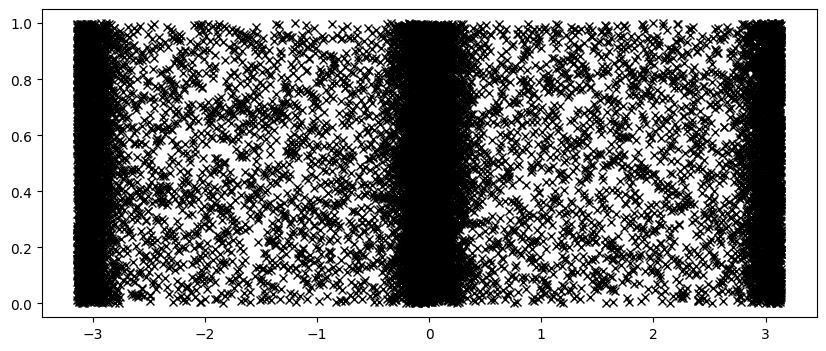

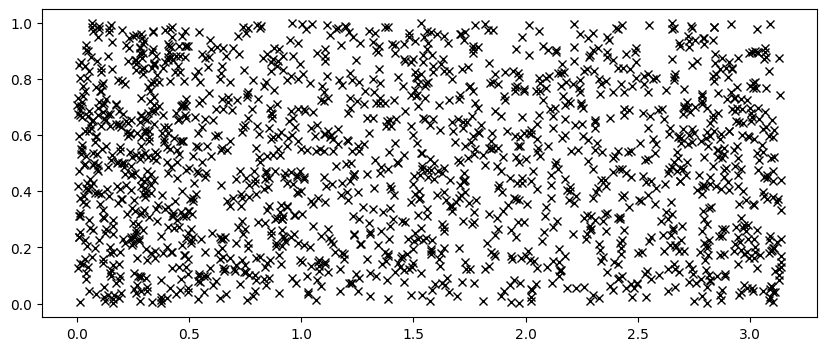

[4.89068760e-18 0.00000000e+00 4.89068760e-17 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.47546354e-02 1.06493828e-02
 4.89068760e-17 1.16878648e+00 4.98000000e-01]


In [ ]:

# number of sampling points
N_smp = 15000
N_fix = [500, 201, 100]  # [col, deri, mid]
N_col = [1000, 121]    # [col, deri]
#coeff = [0.1, 0., 0.]  # [col, deri, mid]
coeff = [0.2, 0.1, 0.1]  # [col, deri, mid] #changed July

# set the size of domain
lmt = jnp.array([pd, scl])


# training freedom
eta0 = 1e-6 #0.01 #0.001 #0.01#0.00001
eta1 = 1e-6 #0.001 #0.01#0.00001
eta_beta = 0 #0.001 #0.01 #0.01 #0.001

# initial guess of the lambda value
#lamb_mod_loaded = trained_params[-1][0]
beta0 = beta1 #-0.001  #-0.01 #0.2 #0.1  #jnp.sqrt(0.005) #beta1 + 0.01   #surface tension, sqrt of beta_phys
lamb0 = 1.168786478283629 #0.767360899999028 #1.0349246792444642/np.sqrt(13) #1.03492434379049 #1.09252709538541 #(1+1/3)**(1/2) #lamb1 #1.0623377106590544 #0.77236216478 #0.766592951360124 #1.0794653821725166  #Velocity, Remind that this is the sqrt of \mu=c^2/g
g= 1. #1 #1. #1 #gravity

# surface tension
#beta = 0.0999998 #1/2#0.089616#0.001
n = 1
m = 3 #2
##target_d2y0 = -(n * n * a_n + m * m * a_m)
epsilon = (scl)**6 #((1+jnp.sqrt(3)/(2*jnp.sqrt(2)))) #error for y''(0), need for surface tension


# set the training iteration
epoch2 = 20000 #24000 #40000 #15000  #was 40000
lw = 0.1
ew =  jnp.array([1.]) #jnp.array([1., 0.05])

# Symmetric condition setting
delta = 0.614151522181624 #+ 0.1 #0.431367994953833 -0.02 -0.01 #0.8 #0.821769294018748 - 0.25 #0 #0.01 #0.04  # degree of asymmetry #y_0-y_pi
sym = True #False  # whether trigger the asymmetric condition or crappers wave

# prepare the normalization condition
x_nm = jnp.array([[0.]])
cond_nm = jnp.array([[y_0]])
# group all the conditions and collocation points
cond = dict(cond_nm=[x_nm, cond_nm])

# prepare the sampling point for HT
# x_smp0 = jnp.linspace(-1, 1, N_smp)
# x_smp = jnp.sign(x_smp0) * jnp.abs(x_smp0) ** 1.4 * jnp.pi
x_smp = data_eqfunc1D([-jnp.pi, jnp.pi], N_smp, lev=200, b=0.05)#lev was 100
# create the hilbert transform function based on the sampling
hptrans = hilb_perid_cubic(x_smp)

fig = plt.figure(figsize=(10, 4), dpi=100)
ax = plt.subplot(111)
ax.plot(x_smp, random.uniform(keys[0], x_smp.shape), 'kx', linewidth=1, label='col.point')
plt.show()

# prepare the collocation points to evaluate equation gradient
dataf, weighf, F0 = data_func_create(N_fix, N_col, coeff)
# sampling the data
data_z = dataf(keys[0], F0)
weigh = weighf(wp=0.1)
data = dwcombine(data_z, weigh)

# # initialize the weights and biases of the
# #trained_params = stwv_init_or_load(keys[1], n_hl, n_unit, weights_path=weights_path) #stwv_init_MLP(keys[1], n_hl, n_unit) #added by Michal
# trained_params = stwv_init_or_load(
#     keys[1],
#     n_hl,
#     n_unit,
#     weights_path=local_weights_path,
#     github_url=github_weights_url,
# )


# read one group of collocation points
x_c = data['col'][0]
x_d = data['grad'][0]

plot = 1
if plot == 1:
    fig = plt.figure(figsize=(10, 4), dpi=100)
    ax = plt.subplot(111)
    ax.plot(x_c, random.uniform(keys[0], x_c.shape), 'kx', linewidth=1, label='col.point')
    plt.show()

# create the solution function
predf = stwv_pred_create(lmt) #training
##predf = stwv_pred_create_test(lmt, m,n) #test
# calculate the loss function
stwv_loss = loss_create(predf, cond, lamb0, beta0, lw, ew)
# update the loss reference based on the real loss
##stwv_loss.ref = stwv_loss(trained_params, data)[0]
stwv_loss.ref = stwv_loss(params, data)[0]
print(stwv_loss(params, data)[1])
#print(stwv_loss(trained_params, data)[1])


In [ ]:
# ============================================================
# Baseline check: does the loaded stage-1 solution still solve the equation?
# ============================================================
# With epsilonp = 0, predf returns the stage-1 solution unchanged, so this is
# purely a check on (checkpoint, lamb0, beta0). e1 is linear in lamb^2, so the
# speed that minimises it follows in closed form -- no scan and no training.
# If the best fit differs from lamb0, the checkpoint and the speed are from
# different runs and every residual below is being scored at the wrong speed.

_x_chk = jnp.linspace(-jnp.pi, jnp.pi, 401)[:, None]
_func = lambda z: predf(params, z)

_f_y = lambda z: _func(z)[:, 0:1]
_f_t1 = lambda z: _func(z)[:, 1:2]
_f_t2 = lambda z: _func(z)[:, 2:3]
_f_yx = lambda z: vectgrad(_f_y, z)[0]
_f_ysqx = lambda z: vectgrad(lambda w: _f_y(w) ** 2, z)[0]
_f_dt2 = lambda z: vectgrad(_f_t2, z)[0]


def _chk(xx):
    y_x, y = vectgrad(_f_y, xx)
    Hy_x = hptrans(xx, _f_yx)
    Hysq_x = hptrans(xx, _f_ysqx)
    dt1, t1 = vectgrad(_f_t1, xx)
    t2 = _f_t2(xx)
    Hdt2 = hptrans(xx, _f_dt2)
    # e1 = -lamb^2 * Hy_x + S,  with S independent of lamb
    S = g * y + g * 0.5 * Hysq_x + g * y * Hy_x + beta0**2 * (-dt1 + Hdt2)
    D = jnp.sqrt(y_x**2 + (1.0 + Hy_x) ** 2)
    return jnp.hstack([Hy_x, S, t2 - (1.0 + Hy_x) / D, t1 - y_x / D])


_P = jnp.vstack([_chk(_x_chk[i:i + 64]) for i in range(0, _x_chk.shape[0], 64)])
_Hy_x, _S, _e2, _e3 = _P[:, 0:1], _P[:, 1:2], _P[:, 2:3], _P[:, 3:4]

_rms = lambda lam: float(jnp.sqrt(jnp.mean((-lam**2 * _Hy_x + _S) ** 2)))
_lamb_fit = float(jnp.sqrt(jnp.sum(_Hy_x * _S) / jnp.sum(_Hy_x * _Hy_x)))

print(f"rms(e1) at lamb0    = {lamb0:.15f} : {_rms(lamb0):.3e}")
print(f"rms(e1) at best fit = {_lamb_fit:.15f} : {_rms(_lamb_fit):.3e}")
print(f"best fit - lamb0    = {_lamb_fit - lamb0:+.3e}")
print(f"max|e2| = {float(jnp.max(jnp.abs(_e2))):.3e}   max|e3| = {float(jnp.max(jnp.abs(_e3))):.3e}")

if abs(_lamb_fit - lamb0) > 1e-6:
    print("\n\u26a0\ufe0f  lamb0 is NOT the speed this checkpoint was trained at.")
    print(f"    Set  lamb1 = {_lamb_fit:.15f}  (or load the checkpoint lamb1 belongs to)")
    print("    and re-run from the weights cell before training.")
else:
    print("\n\u2705 stage-1 solution reproduced; the correction stage can start from here.")


rms(e1) at lamb0    = 1.168786478283629 : 5.560e-09
rms(e1) at best fit = 1.168786476994136 : 5.301e-09
best fit - lamb0    = -1.289e-09
max|e2| = 1.655e-08   max|e3| = 2.272e-08

✅ stage-1 solution reproduced; the correction stage can start from here.


In [ ]:
"""Training using KFAC"""
# training the network using KFAC
##trained_params, loss = kfac_optimizer(keys[2], stwv_loss, kfac_config, trained_params, dataf, F0, epoch2)
params, loss = kfac_optimizer(keys[2], stwv_loss, kfac_config, params, dataf, F0, epoch2) #

# generate the loss history
loss_all = np.array(loss)

Step: 50 | Loss: 3.5985e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.5985e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 9.1385e-09
Step: 100 | Loss: 3.3852e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.3852e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 8.2680e-09
Step: 150 | Loss: 3.2576e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.2576e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 7.4805e-09
Step: 200 | Loss: 3.2009e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.2009e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 6.7679e-09
Step: 250 | Loss: 3.1546e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.1546e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 6.1233e-09
Step: 300 | Loss: 3.0864e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.0864e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 5.5400e-09
Step: 350 | Loss: 3.0446e-18 | Loss_d: 0.0000e+00 | Loss_e: 3.0446e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 5.0123e-09
Step: 400 | Loss: 2.9920e-18 | Loss_d: 0.0000e+00 | Loss_e: 2.9920e-17 | lamb: 1.168786 | beta: 0.498000 | Dp: 4.5349e-09
Step: 450 | Loss: 2.9486e

In [ ]:
# get the inferred lamb
lamb = lamb0 + eta1 * jnp.tanh(params[-1])[0]
##lamb = lamb0 + eta1 * jnp.tanh(trained_params[-1])[0]
beta = beta0 + eta_beta * jnp.tanh(params[-2])[0]
#lamb = lamb0  #for test
print(lamb, beta)

In [ ]:
# calculate the equation residue
f_y = lambda x: predf(params, x)
f_yx = lambda x: vectgrad(f_y, x)[0]

# calculate the solution
x_star = jnp.linspace(-2*jnp.pi, 2*jnp.pi, num=1001)[:, None]

##y_x, y_p = vectgrad(f_y, x_star)
y_x_values, y_values = vectgrad(f_y, x_star)
Hy_p = hptrans(x_star, f_y)
Hy_x = hptrans(x_star, f_yx)

# compute the equation residue
f = stwv_gov_eqn(f_y, x_star, lamb, beta)
df = stwv_deri_eqn(f_y, x_star, lamb, beta)

ExpName = f"WiltonSecondStage_dfq={dfq:.4f}_lamd={lamb:.4f}_beta={beta:.4f}_g={g:.1f}"

#mdic = {"lamb": np.array(lamb), "beta": np.array(beta), "eta": np.array(eta1), "x": np.array(x_star),
 #       "y": np.array(y_p), "Hy": np.array(Hy_p), "Hy_x": np.array(Hy_x),
  #      "y_x": np.array(y_x), "f": np.array(f), "df": df, "loss": loss_all}

mdic = {"lamb": np.array(lamb), "beta": np.array(beta), "eta": np.array(eta1), "x": np.array(x_star),
        "y": np.array(y_values), "Hy": np.array(Hy_p), "Hy_x": np.array(Hy_x),
        "y_x": np.array(y_x_values), "f": np.array(f), "df": df, "loss": loss_all}
FileName = ExpName + '.mat'


# save weights # added by Michal July
weights_path = str(rootdir.joinpath(ExpName + '_weights.pkl'))  # same naming
with open(weights_path, 'wb') as f:
    pickle.dump(params, f)  # added by Michal July

# Saving the output

In [ ]:
FilePath = str(rootdir.joinpath(FileName))
savemat(FilePath, mdic)


In [ ]:
# ============================================================
# Standalone stage-1 sanity check -- touches no notebook state
# ============================================================
import requests as _rq

_s1_url = ("https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
           "StokesWave_lamd%3D1.1688_beta%3D0.4980_g%3D1.0_weights.pkl")
_s1_lamb, _s1_beta, _s1_sclp = 1.168786478283629, 0.4980, 0.27

_r = _rq.get(_s1_url, timeout=60); assert _r.status_code == 200, _r.status_code
open("_s1_check.pkl", "wb").write(_r.content)
_s1_p = pickle.load(open("_s1_check.pkl", "rb"))
print("len =", len(_s1_p), " beta_mod =", _s1_p[-2], " lamb_mod =", _s1_p[-1])

_s1_lmt = jnp.array([jnp.pi, _s1_sclp])
_s1_f  = lambda z: _s1_sclp * neural_net_even(_s1_p[0:3], z, _s1_lmt)
_s1_y  = lambda z: _s1_f(z)[:, 0:1]
_s1_t1 = lambda z: _s1_f(z)[:, 1:2]
_s1_t2 = lambda z: _s1_f(z)[:, 2:3]

def _s1_res(xx):
    y_x, y = vectgrad(_s1_y, xx)
    Hy_x   = hptrans(xx, lambda z: vectgrad(_s1_y, z)[0])
    Hysq_x = hptrans(xx, lambda z: vectgrad(lambda w: _s1_y(w)**2, z)[0])
    dt1, t1 = vectgrad(_s1_t1, xx)
    t2 = _s1_t2(xx)
    Hdt2 = hptrans(xx, lambda z: vectgrad(_s1_t2, z)[0])
    e1 = (-_s1_lamb**2 * Hy_x + g*y + g*0.5*Hysq_x + g*y*Hy_x
          + _s1_beta**2 * (-dt1 + Hdt2))
    D = jnp.sqrt(y_x**2 + (1.0 + Hy_x)**2)
    return jnp.hstack([e1, t2 - (1.0 + Hy_x)/D, t1 - y_x/D])

_s1_x = jnp.linspace(-2*jnp.pi, 2*jnp.pi, 1001)[:, None]
_s1_R = jnp.vstack([_s1_res(_s1_x[i:i+64]) for i in range(0, 1001, 64)])

print(f"\n{'':<6}{'mean_abs':>12}{'rms':>12}{'max_abs':>12}")
for _j, _nm in enumerate(["e1", "e2", "e3"]):
    _r_ = _s1_R[:, _j]
    print(f"{_nm:<6}{float(jnp.mean(jnp.abs(_r_))):>12.3e}"
          f"{float(jnp.sqrt(jnp.mean(_r_**2))):>12.3e}"
          f"{float(jnp.max(jnp.abs(_r_))):>12.3e}")

print("\nexpected:  e1 rms 2.83e-09,  e2 rms 3.68e-09,  e3 rms 3.57e-09")